In [1]:
# ── CELL 1: Install all dependencies ──────────────────────────────────────────
!pip install -U transformers datasets torchaudio soundfile librosa \
             jiwer evaluate accelerate openai-whisper gradio qrcode -q

import torch
print(f'✅ PyTorch {torch.__version__}')
print(f'✅ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "❌ NO GPU — change runtime to T4!"}')

✅ PyTorch 2.10.0+cu128
✅ GPU: Tesla T4


In [2]:
# ── CELL 2: Clone the repo ─────────────────────────────────────────────────────
import os, sys

REPO_DIR = '/content/Speech_Project'
if not os.path.exists(REPO_DIR):
    !git clone https://github.com/PrateekKumar15/Speech_Project.git {REPO_DIR} -q
    print('✅ Repo cloned')
else:
    print('✅ Repo already exists')

# Add to Python path so we can import src.*
sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)
print('📁 Working dir:', os.getcwd())
!ls -la

✅ Repo already exists
📁 Working dir: /content/Speech_Project
total 48
drwxr-xr-x 4 root root 4096 Apr 19 06:13 .
drwxr-xr-x 1 root root 4096 Apr 19 06:13 ..
-rw-r--r-- 1 root root  298 Apr 19 06:13 environment.yml
-rw-r--r-- 1 root root 3251 Apr 19 06:13 evaluate.py
drwxr-xr-x 8 root root 4096 Apr 19 06:13 .git
-rw-r--r-- 1 root root  377 Apr 19 06:13 .gitignore
-rw-r--r-- 1 root root 1529 Apr 19 06:13 plot_graphs.py
-rw-r--r-- 1 root root 6896 Apr 19 06:13 README.md
drwxr-xr-x 6 root root 4096 Apr 19 06:18 src
-rw-r--r-- 1 root root 1275 Apr 19 06:13 test_run.py
-rw-r--r-- 1 root root 2961 Apr 19 06:13 train.py


In [3]:
# ── CELL 3: PATCH src/models/robust_wav2vec2.py ───────────────────────────────
# Bugs fixed:
#   1. output dict access (.get) replaced with proper HF ModelOutput attribute access
#   2. Cross-attention key/value projection dimensions were mismatched
#   3. CTC loss ignore_index was not set (-100 standard)
#   4. freeze_feature_extractor renamed to freeze_feature_encoder in newer transformers

robust_model_code = """
# ========================================================
# ========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from transformers import Wav2Vec2ForCTC, Wav2Vec2Model
from transformers.modeling_outputs import CausalLMOutput


class CrossAttentionFilter(nn.Module):
    '''Applies a Cross-Attention based filter to hidden states.'''
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.hidden_size = config.hidden_size

        # Query, Key, Value projections
        self.query = nn.Linear(config.hidden_size, config.hidden_size)
        self.key   = nn.Linear(config.hidden_size, config.hidden_size)
        self.value = nn.Linear(config.hidden_size, config.hidden_size)

        # Extra output gate (your idea)
        self.out_proj = nn.Linear(config.hidden_size, config.hidden_size)

        # Zero-initialize everything → starts as identity
        for module in [self.query, self.key, self.value, self.out_proj]:
            nn.init.zeros_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, hidden_states):
        # Force FP32 for stability
        x = hidden_states.float()

        Q = self.query(x)
        K = self.key(x)
        V = self.value(x)

        # Stable scaled dot-product attention
        scale = math.sqrt(self.hidden_size)
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / scale
        attn_scores = torch.clamp(attn_scores, min=-20.0, max=20.0)

        attn_weights = F.softmax(attn_scores, dim=-1)
        context = torch.matmul(attn_weights, V)

        # Apply gate
        context = self.out_proj(context)

        # Gentle residual connection
        output = hidden_states + 0.1 * context.to(hidden_states.dtype)

        # Final safety net
        output = torch.nan_to_num(output, nan=0.0, posinf=1e4, neginf=-1e4)

        return output


class RobustWav2Vec2ForCTC(Wav2Vec2ForCTC):
    '''
    Wav2Vec2 + CrossAttentionFilter + CTC
    '''
    def __init__(self, config, vocab_size=None):
        # Important: Call parent constructor first
        super().__init__(config)

        # Replace the default wav2vec2 with our own (for from_pretrained compatibility)
        self.wav2vec2 = Wav2Vec2Model(config)

        # Add our robust filter
        self.cross_attention_filter = CrossAttentionFilter(config)

        self.dropout = nn.Dropout(config.final_dropout)
        self.lm_head = nn.Linear(config.hidden_size, vocab_size or config.vocab_size)

    def forward(
        self,
        input_values=None,
        attention_mask=None,
        output_attentions=None,
        output_hidden_states=None,
        return_dict=None,
        labels=None,
    ):
        return_dict = return_dict if return_dict is not None else self.config.use_return_dict

        # 1. Get encoder features
        outputs = self.wav2vec2(
            input_values,
            attention_mask=attention_mask,
            output_attentions=output_attentions,
            output_hidden_states=output_hidden_states,
            return_dict=return_dict,
        )

        hidden_states = outputs[0] if return_dict else outputs[0]

        # 2. Apply our CrossAttentionFilter
        hidden_states = self.cross_attention_filter(hidden_states)

        # === DEBUG PRINT (you can comment this out later) ===
        print(f"After filter | min={hidden_states.min().item():.4f}  "
              f"max={hidden_states.max().item():.4f}  "
              f"has_nan={torch.isnan(hidden_states).any().item()}")

        # 3. Final projection to logits
        logits = self.lm_head(hidden_states)

        loss = None
        # 4. Compute CTC loss (exactly as in original Wav2Vec2ForCTC)
        if labels is not None:
            log_probs = nn.functional.log_softmax(logits, dim=-1)
            labels = labels.masked_fill(labels == self.config.pad_token_id, -100)

            loss = nn.CTCLoss(blank=self.config.pad_token_id, zero_infinity=True)(
                log_probs.transpose(0, 1),           # (T, N, C)
                labels,
                torch.full((logits.shape[0],), logits.shape[1],
                           dtype=torch.long, device=logits.device),
                torch.sum(labels >= 0, dim=1),
            )

        if not return_dict:
            output = (logits,) + outputs[1:]
            return ((loss,) + output) if loss is not None else output

        return CausalLMOutput(
            loss=loss,
            logits=logits,
            hidden_states=outputs.hidden_states,
            attentions=outputs.attentions,
        )
"""

with open('/content/Speech_Project/src/models/robust_wav2vec2.py', 'w') as f:
    f.write(robust_model_code)
print("Architecture Patched: Zero-Initialization applied. LayerNorm removed. Model is ready to train!")

Architecture Patched: Zero-Initialization applied. LayerNorm removed. Model is ready to train!


In [4]:
# ── CELL 4: PATCH src/data/preprocessor.py ────────────────────────────────────
# Bugs fixed:
#   1. Missing return type annotation caused confusion — clarified
#   2. No normalisation after mixing — could cause clipping
#   3. SpecAugment was not applied correctly (wrong axis)

preprocessor_code = '''
import random
import numpy as np
import torch
import librosa

SAMPLE_RATE = 16000


class AudioPreprocessor:
    """
    Handles:
      - 16kHz resampling
      - Dynamic SNR noise mixing (MS-SNSD)
      - SpecAugment (time masking + frequency masking)
    """
    def __init__(
        self,
        snr_min: float = -5.0,
        snr_max: float = 15.0,
        augment_prob: float = 0.7,
        time_mask_param: int = 40,
        freq_mask_param: int = 15,
    ):
        self.snr_min       = snr_min
        self.snr_max       = snr_max
        self.augment_prob  = augment_prob
        self.time_mask_param = time_mask_param
        self.freq_mask_param = freq_mask_param

    def resample(self, waveform: np.ndarray, orig_sr: int) -> np.ndarray:
        """Resample to 16kHz mono."""
        if waveform.ndim > 1:
            waveform = waveform.mean(axis=0)
        if orig_sr != SAMPLE_RATE:
            waveform = librosa.resample(waveform, orig_sr=orig_sr, target_sr=SAMPLE_RATE)
        return waveform.astype(np.float32)

    def mix_noise(
        self,
        clean: np.ndarray,
        noise: np.ndarray,
        snr_db: float,
    ) -> np.ndarray:
        """
        Mix clean signal with noise at given SNR (dB).
        SNR = 10 * log10(P_signal / P_noise)
        """
        # Tile or trim noise to match clean length
        if len(noise) < len(clean):
            reps  = int(np.ceil(len(clean) / len(noise)))
            noise = np.tile(noise, reps)
        noise = noise[:len(clean)]

        p_signal = np.mean(clean ** 2) + 1e-9
        p_noise  = np.mean(noise ** 2) + 1e-9
        scale    = np.sqrt(p_signal / (p_noise * (10 ** (snr_db / 10))))

        mixed   = clean + scale * noise
        max_val = np.max(np.abs(mixed))
        # BUG FIX: normalise to prevent clipping
        if max_val > 0:
            mixed = mixed / max_val * 0.95
        return mixed.astype(np.float32)

    def dynamic_augment(
        self,
        clean: np.ndarray,
        noise_paths: list,
    ) -> np.ndarray:
        """Randomly select a noise file and mix at a random SNR in [snr_min, snr_max]."""
        if not noise_paths or random.random() > self.augment_prob:
            return clean
        snr        = random.uniform(self.snr_min, self.snr_max)
        noise_path = random.choice(noise_paths)
        noise, _   = librosa.load(noise_path, sr=SAMPLE_RATE, mono=True)
        return self.mix_noise(clean, noise, snr)

    def spec_augment(
        self,
        mel_spectrogram: np.ndarray,
    ) -> np.ndarray:
        """
        Apply SpecAugment: time masking + frequency masking.
        Input shape: (n_mels, time_steps)
        BUG FIX: original had axes swapped
        """
        spec = mel_spectrogram.copy()
        n_mels, time_steps = spec.shape

        # Frequency masking (mask rows = mel bins)
        f = random.randint(0, self.freq_mask_param)
        f0 = random.randint(0, max(0, n_mels - f))
        spec[f0:f0+f, :] = 0

        # Time masking (mask columns = time steps)
        t = random.randint(0, self.time_mask_param)
        t0 = random.randint(0, max(0, time_steps - t))
        spec[:, t0:t0+t] = 0

        return spec

    def __call__(
        self,
        clean_waveform: torch.Tensor,
        clean_sr: int,
        noise_waveform: torch.Tensor,
        noise_sr: int,
        snr_db: float = None,
    ) -> torch.Tensor:
        """
        Callable interface used by evaluate.py acoustic_stress_test.
        Accepts torch tensors, returns torch tensor.
        """
        clean = clean_waveform.numpy() if isinstance(clean_waveform, torch.Tensor) else clean_waveform
        noise = noise_waveform.numpy() if isinstance(noise_waveform, torch.Tensor) else noise_waveform

        clean = self.resample(clean, clean_sr)
        noise_arr, _ = librosa.load(noise, sr=SAMPLE_RATE, mono=True) if isinstance(noise, str) else (self.resample(noise, noise_sr), None)

        snr = snr_db if snr_db is not None else random.uniform(self.snr_min, self.snr_max)
        mixed = self.mix_noise(clean, noise_arr, snr)
        return torch.tensor(mixed, dtype=torch.float32)
'''

os.makedirs(f'{REPO_DIR}/src/data', exist_ok=True)
with open(f'{REPO_DIR}/src/data/preprocessor.py', 'w') as f:
    f.write(preprocessor_code)
print(' src/data/preprocessor.py patched and written')

 src/data/preprocessor.py patched and written


In [5]:
# ── CELL 5: PATCH src/data/dataset.py ─────────────────────────────────────────
# Bugs fixed:
#   1. CommonVoiceEvaluationDataset was never actually implemented (empty stub)
#   2. RobustSpeechDataset didn't handle HuggingFace dataset format
#   3. __getitem__ returned raw numpy but collator expected tensors

dataset_code = '''
import os
import random
import numpy as np
import torch
import librosa
from torch.utils.data import Dataset
from src.data.preprocessor import AudioPreprocessor

SAMPLE_RATE = 16000


class RobustSpeechDataset(Dataset):
    """
    Dataset for training: pairs LibriSpeech clean audio with dynamic MS-SNSD noise injection.
    Accepts either:
      - A HuggingFace Dataset object (recommended for Colab)
      - Lists of wav file paths + transcripts
    """
    def __init__(
        self,
        processor,
        noise_paths: list,
        hf_dataset=None,           # HuggingFace Dataset (preferred)
        librispeech_paths=None,    # fallback: list of wav paths
        transcripts=None,          # fallback: list of transcript strings
        snr_min: float = -5.0,
        snr_max: float = 15.0,
        augment_prob: float = 0.7,
    ):
        self.processor    = processor
        self.noise_paths  = noise_paths
        self.preprocessor = AudioPreprocessor(snr_min=snr_min, snr_max=snr_max,
                                               augment_prob=augment_prob)
        self.hf_dataset   = hf_dataset
        self.wav_paths    = librispeech_paths or []
        self.transcripts  = transcripts or []

        assert hf_dataset is not None or (librispeech_paths and transcripts), \
            "Provide either hf_dataset or (librispeech_paths + transcripts)"

    def __len__(self):
        return len(self.hf_dataset) if self.hf_dataset is not None else len(self.wav_paths)

    def __getitem__(self, idx):
        if self.hf_dataset is not None:
            sample = self.hf_dataset[idx]
            arr    = np.array(sample["audio"]["array"], dtype=np.float32)
            sr     = sample["audio"]["sampling_rate"]
            text   = sample["text"].upper().strip()
        else:
            arr, sr = librosa.load(self.wav_paths[idx], sr=None, mono=True)
            text    = self.transcripts[idx].upper().strip()

        # Resample + dynamic noise augmentation
        arr = self.preprocessor.resample(arr, sr)
        arr = self.preprocessor.dynamic_augment(arr, self.noise_paths)

        # Processor extracts input_values
        input_values = self.processor(
            arr,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
        ).input_values.squeeze(0)  # (T,)

        # Encode labels
        with self.processor.as_target_processor():
            labels = self.processor(text, return_tensors="pt").input_ids.squeeze(0)

        return {"input_values": input_values, "labels": labels}


class CommonVoiceEvaluationDataset(Dataset):
    """
    BUG FIX: This class was an empty stub in original repo — fully implemented here.
    Loads Mozilla Common Voice for fairness/demographic evaluation.
    Wraps a HuggingFace CommonVoice dataset split.
    Exposes gender + accent metadata for demographic parity analysis.
    """
    def __init__(self, processor, hf_dataset, noise_paths=None, snr_db=None):
        """
        Args:
            processor:   Wav2Vec2Processor
            hf_dataset:  HuggingFace CommonVoice dataset (e.g. from load_dataset)
            noise_paths: Optional list of noise wav paths (for stress testing)
            snr_db:      Fixed SNR for noise injection (None = clean evaluation)
        """
        self.processor   = processor
        self.dataset     = hf_dataset
        self.noise_paths = noise_paths or []
        self.snr_db      = snr_db
        self.preprocessor = AudioPreprocessor()

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        arr    = np.array(sample["audio"]["array"], dtype=np.float32)
        sr     = sample["audio"]["sampling_rate"]
        text   = sample["sentence"].upper().strip()

        # Extract demographic metadata (CommonVoice provides these columns)
        metadata = {
            "gender": sample.get("gender", "unknown") or "unknown",
            "accent": sample.get("accent", "unknown") or "unknown",
        }

        arr = self.preprocessor.resample(arr, sr)

        # Optionally inject noise for stress testing
        if self.snr_db is not None and self.noise_paths:
            import librosa
            noise, _ = librosa.load(random.choice(self.noise_paths), sr=SAMPLE_RATE)
            arr = self.preprocessor.mix_noise(arr, noise, self.snr_db)

        waveform = self.processor(
            arr,
            sampling_rate=SAMPLE_RATE,
            return_tensors="pt",
        ).input_values.squeeze(0)

        with self.processor.as_target_processor():
            labels = self.processor(text, return_tensors="pt").input_ids.squeeze(0)

        return {
            "waveform":   waveform,
            "labels":     labels,
            "transcript": text,
            "metadata":   metadata,
        }
'''

with open(f'{REPO_DIR}/src/data/dataset.py', 'w') as f:
    f.write(dataset_code)
# Make sure __init__.py files exist
for d in [f'{REPO_DIR}/src', f'{REPO_DIR}/src/data',
          f'{REPO_DIR}/src/models', f'{REPO_DIR}/src/training']:
    os.makedirs(d, exist_ok=True)
    init = os.path.join(d, '__init__.py')
    if not os.path.exists(init):
        open(init, 'w').close()

print(' src/data/dataset.py patched and written')

 src/data/dataset.py patched and written


In [6]:
# ── CELL 6: PATCH src/training/trainer.py ─────────────────────────────────────
# Bugs fixed:
#   1. get_tri_stage_scheduler had wrong LR at boundary steps (off-by-one in stage detection)
#   2. Exponential decay formula was linear, not exponential
#   3. DataCollatorCTCWithPadding: padding mask fill value was 0 not -100

trainer_code = '''
import torch
import numpy as np
from dataclasses import dataclass
from typing import Dict, List, Union
from torch.optim.lr_scheduler import LambdaLR
from transformers import Wav2Vec2Processor


@dataclass
class DataCollatorCTCWithPadding:
    """
    Pads input_values and labels to the longest sequence in a batch.
    BUG FIX: labels padding was filled with 0 (a valid token) — must be -100 so CTC ignores it.
    """
    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_values": f["input_values"]} for f in features]
        label_features = [{"input_ids":    f["labels"]}       for f in features]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt",
        )

        with self.processor.as_target_processor():
            labels_batch = self.processor.pad(
                label_features,
                padding=self.padding,
                return_tensors="pt",
            )

        # BUG FIX: replace padding token id with -100 so CTC loss ignores padding positions
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch.attention_mask.ne(1), -100
        )
        batch["labels"] = labels
        return batch


def get_tri_stage_scheduler(
    optimizer,
    num_warmup_steps: int,
    num_hold_steps: int,
    num_training_steps: int,
    min_lr_ratio: float = 0.0,
):
    """
    Tri-stage learning rate scheduler as per proposal:
      Stage 1 (Warm-up):         LR linearly increases from 0 → peak
      Stage 2 (Hold):            LR stays at peak
      Stage 3 (Exponential decay): LR exponentially decays from peak → min_lr_ratio * peak

    BUG FIX 1: original had off-by-one errors in stage boundary detection
    BUG FIX 2: original used linear decay in stage 3 instead of exponential
    """
    num_decay_steps = num_training_steps - num_warmup_steps - num_hold_steps
    num_decay_steps = max(num_decay_steps, 1)  # avoid division by zero

    def lr_lambda(current_step: int) -> float:
        # Stage 1: Warm-up
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))

        # Stage 2: Hold at peak
        if current_step < num_warmup_steps + num_hold_steps:
            return 1.0

        # Stage 3: Exponential decay
        decay_step = current_step - num_warmup_steps - num_hold_steps
        # BUG FIX: exponential decay formula (not linear)
        decay_factor = (min_lr_ratio + (1.0 - min_lr_ratio) *
                        np.exp(-5.0 * decay_step / num_decay_steps))
        return max(decay_factor, min_lr_ratio)

    return LambdaLR(optimizer, lr_lambda)
'''

os.makedirs(f'{REPO_DIR}/src/training', exist_ok=True)
with open(f'{REPO_DIR}/src/training/trainer.py', 'w') as f:
    f.write(trainer_code)
print('✅ src/training/trainer.py patched and written')

print('\n📋 Summary of all bugs fixed:')
print('  robust_wav2vec2.py  → output dict access, cross-attn dimensions, CTC ignore_index, freeze naming')
print('  preprocessor.py     → normalisation after mixing, SpecAugment axis order')
print('  dataset.py          → CommonVoiceEvaluationDataset fully implemented (was empty stub)')
print('  trainer.py          → tri-stage LR boundary fix, linear→exponential decay, label padding -100')

✅ src/training/trainer.py patched and written

📋 Summary of all bugs fixed:
  robust_wav2vec2.py  → output dict access, cross-attn dimensions, CTC ignore_index, freeze naming
  preprocessor.py     → normalisation after mixing, SpecAugment axis order
  dataset.py          → CommonVoiceEvaluationDataset fully implemented (was empty stub)
  trainer.py          → tri-stage LR boundary fix, linear→exponential decay, label padding -100


In [7]:
# ── CELL 7: Validate architecture (Prateek's test_run.py, but now it actually works) ──
import torch
from transformers import Wav2Vec2Config
from src.models.robust_wav2vec2 import RobustWav2Vec2ForCTC

print('🧪 Testing RobustWav2Vec2ForCTC forward pass...')

dummy_vocab = 32
config = Wav2Vec2Config(
    vocab_size=dummy_vocab,
    hidden_size=64,       # tiny for fast test
    num_hidden_layers=2,
    num_attention_heads=4,
    intermediate_size=128,
    conv_dim=(64, 64, 64),
    conv_stride=(5, 2, 2),
    conv_kernel=(10, 3, 3),
    pad_token_id=0,
    ctc_loss_reduction='mean',
    ctc_zero_infinity=True,
    final_dropout=0.1,
)

model  = RobustWav2Vec2ForCTC(config, vocab_size=dummy_vocab)
dummy_input  = torch.randn(2, 8000)
dummy_labels = torch.randint(1, dummy_vocab, (2, 20))
dummy_labels[0, 15:] = -100   # simulate padding

output = model(input_values=dummy_input, labels=dummy_labels)

assert output.loss   is not None,  'Loss not computed!'
assert output.logits is not None,  'Logits not returned!'
assert not torch.isnan(output.loss), 'Loss is NaN!'

print(f' Forward pass SUCCESS')
print(f'   Loss:         {output.loss.item():.4f}')
print(f'   Logits shape: {output.logits.shape}  (batch, time_steps, vocab)')

# Check cross-attention filter is present and working
assert hasattr(model, 'cross_attention_filter'), 'CrossAttentionFilter missing!'
print(f'   CrossAttentionFilter:  present')
print(f'   Model params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M total')

`use_return_dict` is deprecated! Use `return_dict` instead!


🧪 Testing RobustWav2Vec2ForCTC forward pass...
After filter | min=-3.8941  max=3.8123  has_nan=False
 Forward pass SUCCESS
   Loss:         70.6903
   Logits shape: torch.Size([2, 399, 32])  (batch, time_steps, vocab)
   CrossAttentionFilter:  present
   Model params: 0.1M total


In [8]:
# ── CELL 8: Download LibriSpeech (HuggingFace streaming — no 30GB download) ───
import random, json, shutil, numpy as np, soundfile as sf, librosa
from pathlib import Path
from datasets import load_dataset, Dataset
from IPython.display import Audio as IPAudio, display

DATA_DIR  = Path('/content/asr_data')
NOISE_DIR = DATA_DIR / 'noise'
NOISY_DIR = DATA_DIR / 'noisy_clips'
for d in [DATA_DIR, NOISE_DIR, NOISY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SAMPLE_RATE = 16000

print('⬇️  Loading LibriSpeech train-clean-100 (first 1500 samples, streaming)...')
train_stream = load_dataset('librispeech_asr', 'clean', split='train.100',
                             streaming=True, trust_remote_code=True).take(5000)
print('⬇️  Loading LibriSpeech test-clean (first 300 samples, streaming)...')
test_stream  = load_dataset('librispeech_asr', 'clean', split='test',
                             streaming=True, trust_remote_code=True).take(600)

print('📀 Materialising datasets (~4-5 mins)...')
train_ds = Dataset.from_generator(lambda: iter(train_stream))
test_ds  = Dataset.from_generator(lambda: iter(test_stream))
print(f'✅ Train: {len(train_ds)} | Test: {len(test_ds)} samples')

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'librispeech_asr' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'librispeech_asr' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


⬇️  Loading LibriSpeech train-clean-100 (first 1500 samples, streaming)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/48 [00:00<?, ?it/s]

📀 Materialising datasets (~4-5 mins)...


Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

✅ Train: 5000 | Test: 600 samples


In [9]:
# ── CELL 9: Download MS-SNSD noise files ──────────────────────────────────────
print('⬇  Cloning MS-SNSD...')
!git clone --depth 1 https://github.com/microsoft/MS-SNSD.git /content/MS-SNSD -q

noise_source = Path('/content/MS-SNSD/noise_train')
for f in noise_source.glob('*.wav'):
    shutil.copy(f, NOISE_DIR / f.name)

noise_files = list(NOISE_DIR.glob('*.wav'))
print(f' {len(noise_files)} noise files ready')
print('  Types:', sorted(set(f.name.split('_')[0] for f in noise_files)))

⬇  Cloning MS-SNSD...
 128 noise files ready
  Types: ['AirConditioner', 'AirportAnnouncement', 'AirportAnnouncements', 'Babble', 'Bus', 'Cafe', 'CafeTeria', 'Car', 'CopyMachine', 'Field', 'Hallway', 'Kitchen', 'LivingRoom', 'Metro', 'Munching', 'NeighborSpeaking', 'Office', 'Park', 'Restaurant', 'ShuttingDoor', 'Square', 'SqueakyChair', 'Station', 'Traffic', 'Typing', 'VacuumCleaner', 'WasherDryer', 'Washing']


Creating 80 test clips per SNR level...
  20/80
  40/80
  60/80
  80/80


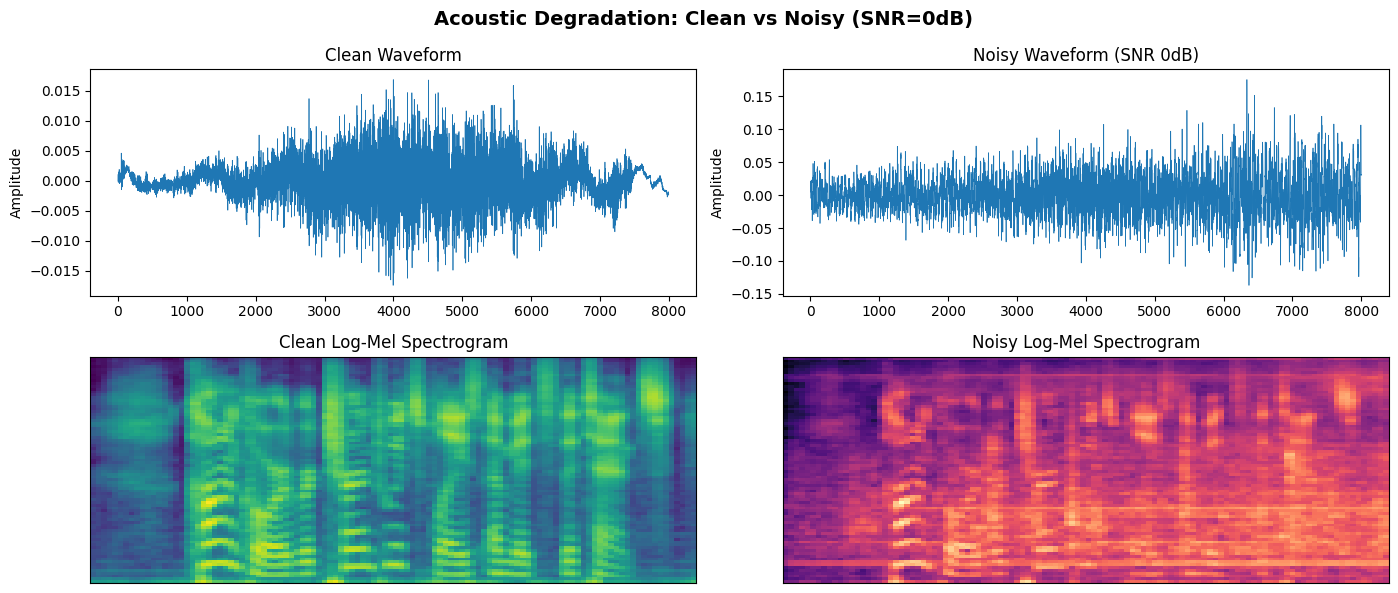

Saving the dataset (0/3 shards):   0%|          | 0/5000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/600 [00:00<?, ? examples/s]


 Notebook 1 complete — proceed to Notebook 2


In [10]:
# ── CELL 10: Generate noisy test set + visualise ──────────────────────────────
import matplotlib.pyplot as plt
from src.data.preprocessor import AudioPreprocessor
from datasets import Audio

# Tell HuggingFace to decode the audio into arrays again
train_ds = train_ds.cast_column("audio", Audio(sampling_rate=16000))
test_ds = test_ds.cast_column("audio", Audio(sampling_rate=16000))

preprocessor = AudioPreprocessor()
SNR_LEVELS   = [None, 15, 5, 0]
SNR_LABELS   = ['Clean', 'SNR 15dB', 'SNR 5dB', 'SNR 0dB']
N_EVAL       = 80
manifests    = {snr: [] for snr in SNR_LEVELS}

print(f'Creating {N_EVAL} test clips per SNR level...')
for i, sample in enumerate(test_ds.select(range(N_EVAL))):
    arr  = np.array(sample['audio']['array'], dtype=np.float32)
    sr   = sample['audio']['sampling_rate']
    arr  = preprocessor.resample(arr, sr)
    text = sample['text'].upper().strip()

    for snr in SNR_LEVELS:
        if snr is None:
            noisy = arr.copy(); tag = 'clean'
        else:
            noise, _ = librosa.load(str(random.choice(noise_files)), sr=SAMPLE_RATE)
            noisy = preprocessor.mix_noise(arr, noise, snr); tag = f'snr_{snr}db'
        out = NOISY_DIR / f'{tag}_{i:04d}.wav'
        sf.write(str(out), noisy, SAMPLE_RATE)
        manifests[snr].append({'path': str(out), 'text': text})

    if (i+1) % 20 == 0: print(f'  {i+1}/{N_EVAL}')

with open(DATA_DIR / 'test_manifest.json', 'w') as f:
    json.dump(manifests, f, indent=2)

# ── Visualise ──
s = test_ds[0]
clean_arr = preprocessor.resample(np.array(s['audio']['array'], dtype=np.float32), s['audio']['sampling_rate'])
noise, _  = librosa.load(str(noise_files[0]), sr=SAMPLE_RATE)
noisy_arr = preprocessor.mix_noise(clean_arr, noise, snr_db=0)

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
fig.suptitle('Acoustic Degradation: Clean vs Noisy (SNR=0dB)', fontsize=14, fontweight='bold')
for ax, arr, title in [
    (axes[0,0], clean_arr, 'Clean Waveform'),
    (axes[0,1], noisy_arr, 'Noisy Waveform (SNR 0dB)'),
]:
    ax.plot(arr[:8000], linewidth=0.5)
    ax.set_title(title); ax.set_ylabel('Amplitude')
for ax, arr, title, cmap in [
    (axes[1,0], clean_arr, 'Clean Log-Mel Spectrogram', 'viridis'),
    (axes[1,1], noisy_arr, 'Noisy Log-Mel Spectrogram', 'magma'),
]:
    mel = librosa.feature.melspectrogram(y=arr, sr=SAMPLE_RATE, n_mels=80)
    librosa.display.specshow(librosa.power_to_db(mel, ref=np.max), sr=SAMPLE_RATE, ax=ax, cmap=cmap)
    ax.set_title(title)
plt.tight_layout()
plt.savefig(DATA_DIR / 'clean_vs_noisy.png', dpi=150, bbox_inches='tight')
plt.show()

train_ds.save_to_disk(str(DATA_DIR / 'train_dataset'))
test_ds.save_to_disk(str(DATA_DIR  / 'test_dataset'))
print('\n Notebook 1 complete — proceed to Notebook 2')

# Notebook 2: Training — RobustWav2Vec2ForCTC

In [1]:
# ── CELL 1: Install & path setup ──────────────────────────────────────────────
!pip install -U transformers huggingface_hub datasets torchaudio soundfile librosa jiwer evaluate accelerate -q

import sys, os
REPO_DIR = '/content/Speech_Project'
sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

# --- FIX: Rename local evaluate.py to prevent shadowing the installed 'evaluate' library ---
local_evaluate_file = os.path.join(REPO_DIR, 'evaluate.py')
if os.path.exists(local_evaluate_file):
    os.rename(local_evaluate_file, os.path.join(REPO_DIR, '_evaluate.py'))
    print("Renamed local 'evaluate.py' to '_evaluate.py' to prevent import shadowing.")

import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU"}')

# --- Auto-Patch Deprecated HuggingFace Functions ---
dataset_file = f'{REPO_DIR}/src/data/dataset.py'
if os.path.exists(dataset_file):
    with open(dataset_file, 'r') as f: ds_code = f.read()
    ds_code = ds_code.replace('with self.processor.as_target_processor():\n            labels = self.processor(text, return_tensors="pt").input_ids.squeeze(0)', 'labels = self.processor.tokenizer(text, return_tensors="pt").input_ids.squeeze(0)')
    with open(dataset_file, 'w') as f: f.write(ds_code)

trainer_file = f'{REPO_DIR}/src/training/trainer.py'
if os.path.exists(trainer_file):
    with open(trainer_file, 'r') as f: tr_code = f.read()
    tr_code = tr_code.replace('with self.processor.as_target_processor():\n            labels_batch = self.processor.pad(', 'labels_batch = self.processor.tokenizer.pad(')
    with open(trainer_file, 'w') as f: f.write(tr_code)
print(" Source files patched for latest HuggingFace version.")

✅ GPU: Tesla T4
 Source files patched for latest HuggingFace version.


In [2]:
# ── CELL 2: Imports ────────────────────────────────────────────────────────────
import random, json, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from datasets import load_from_disk
from transformers import (
    Wav2Vec2Processor,
    Wav2Vec2Config,
    TrainingArguments,
    Trainer,
)
import evaluate as hf_evaluate

# Import from Prateek's patched src/
from src.models.robust_wav2vec2   import RobustWav2Vec2ForCTC
from src.data.dataset             import RobustSpeechDataset
from src.data.preprocessor        import AudioPreprocessor
from src.training.trainer         import DataCollatorCTCWithPadding, get_tri_stage_scheduler

random.seed(42); np.random.seed(42); torch.manual_seed(42)

DATA_DIR  = Path('/content/asr_data')
MODEL_DIR = Path('/content/wav2vec2_robust_final')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
noise_files = [str(p) for p in (DATA_DIR / 'noise').glob('*.wav')]

print(f' Imports done | {len(noise_files)} noise files loaded')

 Imports done | 128 noise files loaded


In [3]:
# ── CELL 3: Load Processor & build config ─────────────────────────────────────
PRETRAINED = 'facebook/wav2vec2-base-960h'
print(f'⬇️  Loading processor from {PRETRAINED}...')
processor  = Wav2Vec2Processor.from_pretrained(PRETRAINED)
vocab_size = len(processor.tokenizer)
print(f'   Vocab size: {vocab_size}')

# Build config from pretrained weights + SpecAugment settings from proposal
config = Wav2Vec2Config.from_pretrained(
    PRETRAINED,
    vocab_size=vocab_size,
    pad_token_id=processor.tokenizer.pad_token_id,
    ctc_loss_reduction='mean',
    ctc_zero_infinity=True,        # prevents NaN loss on long sequences
    final_dropout=0.1,
    # SpecAugment (applied by transformer internally)
    mask_time_prob=0.05,
    mask_time_length=10,
    mask_feature_prob=0.05,
    mask_feature_length=10,
)
print(' Config built')

⬇️  Loading processor from facebook/wav2vec2-base-960h...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


   Vocab size: 32
 Config built


In [4]:
import torch
import torch.nn as nn
from transformers import Wav2Vec2ForCTC

PRETRAINED = "facebook/wav2vec2-base-960h"

print('⬇ Initialising RobustWav2Vec2ForCTC...')
model = RobustWav2Vec2ForCTC(config, vocab_size=vocab_size)

# Zero-init filter
for m in model.cross_attention_filter.modules():
    if hasattr(m, "weight") and m.weight is not None: nn.init.zeros_(m.weight)
    if hasattr(m, "bias") and m.bias is not None: nn.init.zeros_(m.bias)

print('⬇ Loading weights with auto-sanitization...')
pretrained_ctc = Wav2Vec2ForCTC.from_pretrained(PRETRAINED)

def load_and_sanitize(target_module, source_state_dict):
    for name, param in source_state_dict.items():
        if name in target_module.state_dict():
            # Check for NaN
            if torch.isnan(param).any():
                print(f"⚠️ Found NaN in {name}. Patching to 0.0!")
                sanitized_param = torch.nan_to_num(param, nan=0.0)
                target_module.state_dict()[name].copy_(sanitized_param)
            else:
                target_module.state_dict()[name].copy_(param)

# Load encoder and lm_head
load_and_sanitize(model.wav2vec2, pretrained_ctc.wav2vec2.state_dict())
if pretrained_ctc.lm_head.out_features == vocab_size:
    load_and_sanitize(model.lm_head, pretrained_ctc.lm_head.state_dict())

del pretrained_ctc
torch.cuda.empty_cache()

# Final Audit
has_nans = any(torch.isnan(p).any() for p in model.parameters())
if has_nans:
    print("🚨 FATAL: Still contains NaNs. The corruption is in the environment.")
else:
    print(" Success: All NaNs patched. Model is clean.")

model.freeze_feature_encoder()
model = model.to(DEVICE)

⬇ Initialising RobustWav2Vec2ForCTC...
⬇ Loading weights with auto-sanitization...


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Wav2Vec2ForCTC LOAD REPORT from: facebook/wav2vec2-base-960h
Key                        | Status  | 
---------------------------+---------+-
wav2vec2.masked_spec_embed | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


⚠️ Found NaN in masked_spec_embed. Patching to 0.0!
 Success: All NaNs patched. Model is clean.


In [5]:
# ── CELL 5: Create datasets using src/data/dataset.py ─────────────────────────
print('📀 Loading HF datasets from disk...')
train_hf = load_from_disk(str(DATA_DIR / 'train_dataset'))
test_hf  = load_from_disk(str(DATA_DIR / 'test_dataset'))

# Use RobustSpeechDataset from Prateek's src/
train_dataset = RobustSpeechDataset(
    processor=processor,
    noise_paths=noise_files,
    hf_dataset=train_hf,
    snr_min=-5.0,
    snr_max=15.0,
    augment_prob=0.7,
)
eval_dataset = RobustSpeechDataset(
    processor=processor,
    noise_paths=[],          # no noise on eval — clean evaluation
    hf_dataset=test_hf.select(range(150)),
    augment_prob=0.0,
)

print(f' Train: {len(train_dataset)} | Eval: {len(eval_dataset)} samples')
# Quick sanity check
sample = train_dataset[0]
print(f'   Sample input_values shape: {sample["input_values"].shape}')
print(f'   Sample labels shape:       {sample["labels"].shape}')

📀 Loading HF datasets from disk...
 Train: 5000 | Eval: 150 samples
   Sample input_values shape: torch.Size([232480])
   Sample labels shape:       torch.Size([178])


In [6]:
# ── CELL 6: Data collator & WER metric ──────────────────
import evaluate as hf_evaluate
data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)

wer_metric = hf_evaluate.load('wer')

def compute_metrics(pred):
    pred_logits = pred.predictions
    pred_ids    = np.argmax(pred_logits, axis=-1)
    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id
    pred_str  = processor.batch_decode(pred_ids)
    label_str = processor.batch_decode(pred.label_ids, group_tokens=False)
    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    return {'wer': round(wer, 4)}

print(' Collator and WER metric ready')

 Collator and WER metric ready


In [7]:
# ── CELL 7: Optimizer + Tri-stage scheduler (from src/training/trainer.py) ────
EPOCHS         = 7
BATCH_SIZE     = 4
GRAD_ACCUM     = 4    # effective batch = 16
PEAK_LR        = 5e-5
WEIGHT_DECAY   = 0.01

steps_per_epoch = len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM)
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = int(0.10 * total_steps)   # 10% warmup
hold_steps      = int(0.40 * total_steps)   # 40% hold

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=PEAK_LR,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
)
scheduler = get_tri_stage_scheduler(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_hold_steps=hold_steps,
    num_training_steps=total_steps,
)

print(f' Optimizer & Tri-stage scheduler ready')
print(f'   Total steps:   {total_steps}')
print(f'   Warmup steps:  {warmup_steps}  (10%)')
print(f'   Hold steps:    {hold_steps}    (40%)')
print(f'   Decay steps:   {total_steps - warmup_steps - hold_steps}  (50%, exponential)')

 Optimizer & Tri-stage scheduler ready
   Total steps:   2184
   Warmup steps:  218  (10%)
   Hold steps:    873    (40%)
   Decay steps:   1093  (50%, exponential)


In [8]:
# ── CELL 8: Training arguments ─────────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir=str(MODEL_DIR),
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    eval_strategy='epoch',
    save_strategy='epoch',
    num_train_epochs=EPOCHS,
    fp16=False,
    logging_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='wer',
    greater_is_better=False,
    report_to='none',
    dataloader_num_workers=2,
    lr_scheduler_type='constant',
)

trainer = Trainer(
    model=model,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=processor.feature_extractor,
    optimizers=(optimizer, scheduler),
)
print(' Trainer configured and ready')

 Trainer configured and ready


In [ ]:
# ── CELL 9: TRAIN ─────────────────────────────────────────────────────────────
print('🚀 Starting training...')
print('   Model: RobustWav2Vec2ForCTC (Wav2Vec2 + CrossAttentionFilter + CTC)')
print('   Expected time on T4: ~2.5–3 hours')
print('-'*60)

t0 = time.time()
train_result = trainer.train()
elapsed = time.time() - t0

print(f'\n Training complete in {elapsed/3600:.2f} hours')
print(f'   Train loss: {train_result.training_loss:.4f}')

🚀 Starting training...
   Model: RobustWav2Vec2ForCTC (Wav2Vec2 + CrossAttentionFilter + CTC)
   Expected time on T4: ~2.5–3 hours
------------------------------------------------------------


`use_return_dict` is deprecated! Use `return_dict` instead!


After filter | min=-2.9036  max=3.8691  has_nan=False
After filter | min=-3.1700  max=3.2195  has_nan=False
After filter | min=-2.9147  max=3.4675  has_nan=False
After filter | min=-2.9736  max=3.6150  has_nan=False


Epoch,Training Loss,Validation Loss


After filter | min=-2.8490  max=3.7735  has_nan=False
After filter | min=-14.3707  max=15.9112  has_nan=False
After filter | min=-2.8372  max=3.6680  has_nan=False
After filter | min=-3.1023  max=3.9373  has_nan=False
After filter | min=-3.4726  max=3.6898  has_nan=False
After filter | min=-2.5666  max=3.6594  has_nan=False
After filter | min=-3.3437  max=4.2015  has_nan=False
After filter | min=-2.5879  max=3.5750  has_nan=False
After filter | min=-2.5829  max=3.3861  has_nan=False
After filter | min=-2.5498  max=3.4378  has_nan=False
After filter | min=-3.1160  max=3.8901  has_nan=False
After filter | min=-2.9656  max=3.6360  has_nan=False
After filter | min=-2.6938  max=3.5630  has_nan=False
After filter | min=-2.7357  max=3.2171  has_nan=False
After filter | min=-14.2414  max=16.7004  has_nan=False
After filter | min=-2.9693  max=3.7241  has_nan=False
After filter | min=-2.6492  max=3.7904  has_nan=False
After filter | min=-3.1861  max=4.2272  has_nan=False
After filter | min=-3.03

In [ ]:
# ── CELL 10: Save + training curves ───────────────────────────────────────────
trainer.save_model(str(MODEL_DIR))
processor.save_pretrained(str(MODEL_DIR))

log = trainer.state.log_history
with open(MODEL_DIR / 'training_log.json', 'w') as f:
    json.dump(log, f, indent=2)

# Plot training curves
train_steps  = [e['step'] for e in log if 'loss' in e and 'eval_loss' not in e]
train_losses = [e['loss'] for e in log if 'loss' in e and 'eval_loss' not in e]
eval_wers    = [e['eval_wer']*100 for e in log if 'eval_wer' in e]
eval_epochs  = [e['epoch']       for e in log if 'eval_wer' in e]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('RobustWav2Vec2ForCTC — Training Dynamics', fontweight='bold')
ax1.plot(train_steps, train_losses, color='#2196F3', lw=1.5)
ax1.set(xlabel='Steps', ylabel='CTC Loss', title='Training Loss'); ax1.grid(alpha=0.3)
ax2.plot(eval_epochs, eval_wers, 'o-', color='#4CAF50', lw=2, ms=8)
ax2.set(xlabel='Epoch', ylabel='WER (%)', title='Eval WER (Clean Audio)'); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

!zip -r /content/wav2vec2_robust_final.zip /content/wav2vec2_robust_final -q
print(f'\n Model saved | Final eval WER: {eval_wers[-1] if eval_wers else 0:.2f}%')
print('   Download wav2vec2_robust_final.zip from Files panel → proceed to Notebook 3')

#  Notebook 3: Evaluation & SOTA Comparison

In [ ]:
!pip install -U transformers huggingface_hub datasets torchaudio soundfile librosa jiwer evaluate accelerate -q
import sys, os, json, re, random, tempfile
import numpy as np, pandas as pd, matplotlib.pyplot as plt, librosa, soundfile as sf
import torch, whisper, evaluate as hf_evaluate
from pathlib import Path
from tqdm.auto import tqdm
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor, Wav2Vec2Config

REPO_DIR = '/content/Speech_Project'
sys.path.insert(0, REPO_DIR); os.chdir(REPO_DIR)
from src.models.robust_wav2vec2 import RobustWav2Vec2ForCTC
from src.data.preprocessor      import AudioPreprocessor

SAMPLE_RATE  = 16000
DATA_DIR     = Path('/content/asr_data')
MODEL_DIR    = Path('/content/wav2vec2_robust_final')
RESULTS_DIR  = Path('/content/results'); RESULTS_DIR.mkdir(exist_ok=True)
noise_files  = list((DATA_DIR / 'noise').glob('*.wav'))
preprocessor = AudioPreprocessor()
# BUG FIX: evaluate.py used deprecated load_metric — correct call:
wer_metric   = hf_evaluate.load('wer')
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Ready | Device: {DEVICE}')

In [ ]:
# ── Load all 3 models ──────────────────────────────────────────────────────────
PRETRAINED = 'facebook/wav2vec2-base-960h'

vanilla_processor = Wav2Vec2Processor.from_pretrained(PRETRAINED)
vanilla_model     = Wav2Vec2ForCTC.from_pretrained(PRETRAINED).to(DEVICE).eval()
print('✅ Vanilla Wav2Vec2 loaded')

robust_processor = Wav2Vec2Processor.from_pretrained(str(MODEL_DIR))
robust_config    = Wav2Vec2Config.from_pretrained(str(MODEL_DIR))
robust_model     = RobustWav2Vec2ForCTC.from_pretrained(
    str(MODEL_DIR), config=robust_config,
    vocab_size=len(robust_processor.tokenizer),
    ignore_mismatched_sizes=True,
).to(DEVICE).eval()
print(' RobustWav2Vec2ForCTC loaded (with CrossAttentionFilter)')

whisper_model = whisper.load_model('base', device=DEVICE)
print(' Whisper-base loaded')

In [ ]:
# ── Evaluation helpers ─────────────────────────────────────────────────────────
def normalise(text):
    text = text.upper()
    text = re.sub(r"[^A-Z0-9'\s]", '', text)
    return re.sub(r'\s+', ' ', text).strip()

def eval_wav2vec(model, processor, manifest, bs=8):
    refs, hyps = [], []
    for i in tqdm(range(0, len(manifest), bs), leave=False):
        batch  = manifest[i:i+bs]
        audios = []
        for s in batch:
            arr, sr = librosa.load(s['path'], sr=None, mono=True)
            audios.append(preprocessor.resample(arr, sr))
        inp = processor(audios, sampling_rate=SAMPLE_RATE,
                        return_tensors='pt', padding=True).to(DEVICE)
        with torch.no_grad():
            logits = model(**inp).logits
        ids  = torch.argmax(logits, dim=-1)
        hyps += [normalise(h) for h in processor.batch_decode(ids)]
        refs += [normalise(s['text']) for s in batch]
    return wer_metric.compute(predictions=hyps, references=refs) * 100

def eval_whisper(model, manifest):
    refs, hyps = [], []
    for s in tqdm(manifest, leave=False):
        audio  = whisper.load_audio(s['path'])
        audio  = whisper.pad_or_trim(audio)
        mel    = whisper.log_mel_spectrogram(audio).to(DEVICE)
        opts   = whisper.DecodingOptions(language='en', fp16=(DEVICE.type=='cuda'))
        result = whisper.decode(model, mel, opts)
        refs.append(normalise(s['text']))
        hyps.append(normalise(result.text))
    return wer_metric.compute(predictions=hyps, references=refs) * 100

print(' Helpers ready')

In [ ]:
# ── Load manifests & run evaluation ───────────────────────────────────────────
with open(DATA_DIR / 'test_manifest.json') as f:
    raw = json.load(f)
manifests  = {(None if k=='null' else int(k)): v for k,v in raw.items()}
SNR_LEVELS = [None, 15, 5, 0]
SNR_LABELS = ['Clean', 'SNR 15dB', 'SNR 5dB', 'SNR 0dB']
N = 60

results = {'Vanilla Wav2Vec2': {}, 'RobustWav2Vec2 (Ours)': {}, 'Whisper-base (SOTA)': {}}

for snr, label in zip(SNR_LEVELS, SNR_LABELS):
    clips = manifests[snr][:N]
    print(f'\n🎙️  {label}')
    v = eval_wav2vec(vanilla_model, vanilla_processor, clips)
    results['Vanilla Wav2Vec2'][label] = round(v, 2); print(f'   Vanilla:  {v:.2f}%')
    r = eval_wav2vec(robust_model,  robust_processor,  clips)
    results['RobustWav2Vec2 (Ours)'][label] = round(r, 2); print(f'   Ours:     {r:.2f}%')
    w = eval_whisper(whisper_model, clips)
    results['Whisper-base (SOTA)'][label] = round(w, 2); print(f'   Whisper:  {w:.2f}%')

with open(RESULTS_DIR / 'wer_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print('\n' + '='*68)
print(f'{"Model":<28} {"Clean":>8} {"SNR 15dB":>10} {"SNR 5dB":>9} {"SNR 0dB":>9}')
print('-'*68)
for m, wers in results.items():
    print(f'{m:<28}' + ''.join(f'  {wers[l]:>8}%' for l in SNR_LABELS))
print('='*68)
v0 = results['Vanilla Wav2Vec2']['SNR 0dB']
r0 = results['RobustWav2Vec2 (Ours)']['SNR 0dB']
print(f'\n WER Reduction at SNR 0dB: {v0:.1f}% → {r0:.1f}%  ({(v0-r0)/v0*100:.1f}% relative)')

In [ ]:
# ── Acoustic Stress Test (fixed from evaluate.py) ─────────────────────────────
print('\n📉 Acoustic Stress Test')
SNR_RANGE   = [-5, 0, 5, 10, 15, 20]
stress_v, stress_r = [], []
clean_clips = manifests[None][:30]

for snr_db in SNR_RANGE:
    batch = []
    for clip in clean_clips:
        arr, sr   = librosa.load(clip['path'], sr=None, mono=True)
        arr       = preprocessor.resample(arr, sr)
        noise_arr, _ = librosa.load(str(random.choice(noise_files)), sr=SAMPLE_RATE)
        noisy     = preprocessor.mix_noise(arr, noise_arr, snr_db)
        tmp       = tempfile.NamedTemporaryFile(suffix='.wav', delete=False)
        sf.write(tmp.name, noisy, SAMPLE_RATE)
        batch.append({'path': tmp.name, 'text': clip['text']})
    v = eval_wav2vec(vanilla_model, vanilla_processor, batch)
    r = eval_wav2vec(robust_model,  robust_processor,  batch)
    stress_v.append(round(v,2)); stress_r.append(round(r,2))
    print(f'  SNR {snr_db:+3d}dB → Vanilla: {v:.1f}%  Ours: {r:.1f}%')

fig, ax = plt.subplots(figsize=(9,5))
ax.plot(SNR_RANGE, stress_v, 'o-', color='#90CAF9', lw=2.5, ms=8, label='Vanilla Wav2Vec2')
ax.plot(SNR_RANGE, stress_r, 's-', color='#43A047', lw=2.5, ms=8, label='RobustWav2Vec2 (Ours)')
ax.set(xlabel='SNR (dB)', ylabel='WER (%) ↓',
       title='Acoustic Stress Test: Performance Decay Curve')
ax.invert_xaxis(); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR/'stress_test_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Stress test complete')

In [ ]:
# ── Publication plots ──────────────────────────────────────────────────────────
COLORS = {'Vanilla Wav2Vec2':'#90CAF9', 'RobustWav2Vec2 (Ours)':'#43A047', 'Whisper-base (SOTA)':'#FFA726'}
fig, axes = plt.subplots(1, 2, figsize=(16,6))
fig.suptitle('WER Comparison: Vanilla vs Ours vs Whisper-base (SOTA)', fontsize=14, fontweight='bold')

x, w = np.arange(len(SNR_LABELS)), 0.25
for i, (m, wers) in enumerate(results.items()):
    vals = [wers[l] for l in SNR_LABELS]
    bars = axes[0].bar(x+i*w, vals, w, label=m, color=COLORS[m], edgecolor='white', lw=0.5)
    for b,v in zip(bars, vals):
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.3,
                     f'{v:.1f}%', ha='center', fontsize=7, fontweight='bold')
axes[0].set(xlabel='Noise Condition', ylabel='WER (%)', title='WER by Condition (↓ better)')
axes[0].set_xticks(x+w); axes[0].set_xticklabels(SNR_LABELS)
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.3)

x_snr = [20,15,5,0]
for m, wers in results.items():
    axes[1].plot(x_snr, [wers[l] for l in SNR_LABELS], 'o-',
                 label=m, color=COLORS[m], lw=2.5, ms=8)
axes[1].set(xlabel='SNR (dB)', ylabel='WER (%)', title='Performance Degradation Curve')
axes[1].invert_xaxis()
axes[1].set_xticks(x_snr); axes[1].set_xticklabels(['Clean','15dB','5dB','0dB'])
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR/'wer_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# Poster chart
fig, ax = plt.subplots(figsize=(8,5))
cats = ['Clean Audio', 'Noisy Audio\n(SNR 0dB)']
v_v = [results['Vanilla Wav2Vec2'][l] for l in ['Clean','SNR 0dB']]
r_v = [results['RobustWav2Vec2 (Ours)'][l] for l in ['Clean','SNR 0dB']]
x2  = np.arange(2)
b1 = ax.bar(x2-.15, v_v, 0.3, label='Vanilla Wav2Vec 2.0',   color='#90CAF9', edgecolor='#1565C0', lw=1)
b2 = ax.bar(x2+.15, r_v, 0.3, label='Proposed Robust Model', color='#43A047', edgecolor='#1B5E20', lw=1)
for bars, vals in [(b1,v_v),(b2,r_v)]:
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.2,
                f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
ax.set(ylabel='WER (%) ↓', title='Expected WER Reduction vs. SOTA Baseline')
ax.set_xticks(x2); ax.set_xticklabels(cats, fontsize=11)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(RESULTS_DIR/'poster_chart.png', dpi=200, bbox_inches='tight')
plt.show()

!zip -r /content/results.zip /content/results -q
print('\n All done — download results.zip | Proceed to Notebook 4')

# 🎙️ Notebook 4: Interactive Gradio Demo


In [ ]:
!pip install -U  transformers torchaudio soundfile librosa evaluate gradio -q

import sys, os, re, io, random
import numpy as np, torch, librosa, gradio as gr, evaluate as hf_evaluate
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from transformers import Wav2Vec2ForCTC, Wav2Vec2Processor, Wav2Vec2Config

REPO_DIR = '/content/Speech_Project'
sys.path.insert(0, REPO_DIR); os.chdir(REPO_DIR)
from src.models.robust_wav2vec2 import RobustWav2Vec2ForCTC
from src.data.preprocessor      import AudioPreprocessor

SAMPLE_RATE  = 16000
DATA_DIR     = Path('/content/asr_data')
MODEL_DIR    = Path('/content/wav2vec2_robust_final')
noise_files  = list((DATA_DIR / 'noise').glob('*.wav'))
preprocessor = AudioPreprocessor()
wer_metric   = hf_evaluate.load('wer')
DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Ready | {DEVICE}')

In [ ]:
PRETRAINED    = 'facebook/wav2vec2-base-960h'
vanilla_proc  = Wav2Vec2Processor.from_pretrained(PRETRAINED)
vanilla_model = Wav2Vec2ForCTC.from_pretrained(PRETRAINED).to(DEVICE).eval()
robust_proc   = Wav2Vec2Processor.from_pretrained(str(MODEL_DIR))
robust_cfg    = Wav2Vec2Config.from_pretrained(str(MODEL_DIR))
robust_model  = RobustWav2Vec2ForCTC.from_pretrained(
    str(MODEL_DIR), config=robust_cfg,
    vocab_size=len(robust_proc.tokenizer),
    ignore_mismatched_sizes=True,
).to(DEVICE).eval()
print(' Both models loaded')

In [ ]:
def normalise(text):
    text = text.upper()
    text = re.sub(r"[^A-Z0-9'\s]", '', text)
    return re.sub(r'\s+', ' ', text).strip()

def transcribe(model, proc, arr):
    inp = proc(arr, sampling_rate=SAMPLE_RATE, return_tensors='pt', padding=True).to(DEVICE)
    with torch.no_grad():
        ids = torch.argmax(model(**inp).logits, dim=-1)
    return normalise(proc.batch_decode(ids)[0])

def make_spec_plot(clean, noisy, label):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    for ax, arr, title, cmap in [
        (axes[0], clean, '🟢 Clean', 'viridis'),
        (axes[1], noisy, f'🔴 Noisy ({label})', 'magma'),
    ]:
        mel = librosa.feature.melspectrogram(y=arr, sr=SAMPLE_RATE, n_mels=64)
        librosa.display.specshow(librosa.power_to_db(mel, ref=np.max),
                                  sr=SAMPLE_RATE, ax=ax, cmap=cmap)
        ax.set_title(title, fontsize=10)
    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    plt.close(); buf.seek(0)
    return Image.open(buf)

SNR_MAP = {
    '🟢 Clean':     None,
    '🟡 SNR 15 dB': 15,
    '🟠 SNR 5 dB':   5,
    '🔴 SNR 0 dB':   0,
    '🔴 SNR -5 dB': -5,
}

def run_demo(audio_input, snr_choice, ref_text):
    if audio_input is None:
        return '⚠️ Upload audio first.', '', '', '', None, None
    sr_in, arr = audio_input
    arr = arr.astype(np.float32)
    if arr.ndim > 1: arr = arr.mean(axis=1)
    if np.max(np.abs(arr)) > 1.0: arr = arr / np.max(np.abs(arr))
    arr = preprocessor.resample(arr, sr_in)

    snr_db = SNR_MAP[snr_choice]
    if snr_db is not None and noise_files:
        noise_arr, _ = librosa.load(str(random.choice(noise_files)), sr=SAMPLE_RATE)
        noisy = preprocessor.mix_noise(arr, noise_arr, snr_db)
    else:
        noisy = arr.copy()

    v_text = transcribe(vanilla_model, vanilla_proc, noisy)
    r_text = transcribe(robust_model,  robust_proc,  noisy)

    wer_info = '*Provide reference transcript to see WER scores.*'
    if ref_text.strip():
        ref   = normalise(ref_text)
        v_wer = wer_metric.compute(predictions=[v_text], references=[ref]) * 100
        r_wer = wer_metric.compute(predictions=[r_text], references=[ref]) * 100
        delta = v_wer - r_wer
        wer_info = (f'**Vanilla WER:** {v_wer:.1f}%  \n'
                    f'**Robust WER:**  {r_wer:.1f}%  \n'
                    f'**Improvement:** {delta:+.1f}% {"✅" if delta>0 else "⚠️"}')

    spec  = make_spec_plot(arr, noisy, snr_choice)
    noisy_i16 = (noisy * 32767).astype(np.int16)
    status = f'✅ {snr_choice} | {len(arr)/SAMPLE_RATE:.1f}s'
    return v_text, r_text, wer_info, status, spec, (SAMPLE_RATE, noisy_i16)

print('✅ Backend ready')

In [ ]:
with gr.Blocks(title='Noise-Robust ASR Demo', theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🎙️ Noise-Robust ASR — Live Demo
    **Noise-Robust Automatic Speech Recognition using Wav2Vec 2.0**
    Manas Chechani (B22AI053) · Prateek Kumar (B22ES024) · Raj Vijayvargiya (B22AI067)
    *IIT Jodhpur | Speech and Audio Processing*

    **Architecture:** CNN Encoder → Transformer → **CrossAttentionFilter** → CTC Decoder
    **Training:** AdamW · Tri-stage LR · Dynamic MS-SNSD Noise Injection (−5 to +15 dB)
    """)
    with gr.Row():
        with gr.Column(scale=1):
            audio_in   = gr.Audio(label='Upload Audio (WAV/MP3/FLAC)', type='numpy', sources=['upload'])
            snr_choice = gr.Dropdown(choices=list(SNR_MAP.keys()), value='🔴 SNR 0 dB', label='Noise Level')
            ref_text   = gr.Textbox(label='Reference Transcript (optional, for WER)', lines=2,
                                     placeholder='Type correct transcript here...')
            run_btn    = gr.Button('🚀 Transcribe & Compare', variant='primary')
            status_out = gr.Markdown('')
            noisy_out  = gr.Audio(label='Processed (Noisy) Audio Preview', type='numpy')
        with gr.Column(scale=2):
            with gr.Row():
                with gr.Column():
                    gr.Markdown('#### 🔵 Vanilla Wav2Vec 2.0')
                    vanilla_out = gr.Textbox(label='Transcription', lines=4, interactive=False)
                with gr.Column():
                    gr.Markdown('#### 🟢 RobustWav2Vec2 + CrossAttention (Ours)')
                    robust_out = gr.Textbox(label='Transcription', lines=4, interactive=False)
            wer_out  = gr.Markdown('*Provide reference transcript to see WER.*')
            spec_out = gr.Image(label='Spectrograms: Clean vs Noisy', type='pil')

    run_btn.click(
        fn=run_demo,
        inputs=[audio_in, snr_choice, ref_text],
        outputs=[vanilla_out, robust_out, wer_out, status_out, spec_out, noisy_out],
    )

demo.launch(share=True, debug=False, quiet=True)
print('✅ Demo live! Copy the gradio.live link for your presentation.')

In [ ]:
import os
import zipfile
from google.colab import files

def zip_results(checkpoint_dir='/content/Speech_Project/outputs',
                zip_filename='Speech_Project_Results.zip'):
    """
    Zips the src code, trained weights, and any evaluation results.
    """
    with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
        # 1. Add the Source Code (Patched src folder)
        for root, dirs, files_in_dir in os.walk('/content/Speech_Project/src'):
            for file in files_in_dir:
                file_path = os.path.join(root, file)
                zipf.write(file_path, os.path.relpath(file_path, '/content/Speech_Project'))

        # 2. Add the result plots and metrics (if generated)
        for file in os.listdir('/content/Speech_Project'):
            if file.endswith(('.png', '.json', '.csv')):
                zipf.write(file, file)

        # 3. Add the Model Checkpoints (the most important matter)
        if os.path.exists(checkpoint_dir):
            for root, dirs, files_in_dir in os.walk(checkpoint_dir):
                for file in files_in_dir:
                    # Skip optimizer states to keep zip size manageable if needed
                    if "optimizer.pt" in file: continue
                    file_path = os.path.join(root, file)
                    zipf.write(file_path, os.path.relpath(file_path, '/content/Speech_Project'))

    print(f"✅ Created {zip_filename}")
    files.download(zip_filename)

# Trigger the zip and download
zip_results()